# Feature Engineering Models

## Objective
In this notebook, I build a feature-based forecasting pipeline using the cleaned time series.

The goal is to transform the original time series into a structured dataset with engineered features such as calendar variables, lag features, rolling statistics, and external signals like oil prices and holidays.

The models in this notebook will be trained on data from **2013-01-01 to 2013-12-31** and evaluated on data from **2014-01-01 to 2014-03-31**.

# 1. Environment Setup

In [1]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt

# 2. Data Loading

In [ ]:
# Load the cleaned main time series
timeseries = pd.read_csv("../../data/timeseries_cleaned.csv")

# Load the processed oil dataset prepared in the previous notebook
oil = pd.read_csv("../../data/processed/oil_interpolated.csv")

# Load the holidays dataset from the raw data folder
holidays = pd.read_csv("../../data/raw/holidays.csv")

# 3. Data Exploration

In [3]:
# Display the first rows of each dataset
display(timeseries.head())
display(oil.head())
display(holidays.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


,date,dcoilwtico,oil_price_interpolated
0,2013-01-01,NaN,93.14
1,2013-01-02,93.14,93.14
2,2013-01-03,92.97,92.97
3,2013-01-04,93.12,93.12
4,2013-01-07,93.20,93.20


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [4]:
# Check the shape of each dataset
print("Timeseries shape:", timeseries.shape)
print("Oil shape:", oil.shape)
print("Holidays shape:", holidays.shape)

Timeseries shape: (454, 2)
Oil shape: (1218, 3)
Holidays shape: (350, 4)


In [5]:
# Check basic information about each dataset
timeseries.info()
oil.info()
holidays.info()

<class 'pandas.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        454 non-null    str    
 1   unit_sales  454 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    1218 non-null   str    
 1   dcoilwtico              1175 non-null   float64
 2   oil_price_interpolated  1218 non-null   float64
dtypes: float64(2), str(1)
memory usage: 28.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   locale       350 non-null    str  
 2   locale_name  350 non-null   

In [6]:
# Convert date columns to datetime format
timeseries["date"] = pd.to_datetime(timeseries["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

In [9]:
# Quick validation of the cleaned time series from Week 1

print("Date range:", timeseries["date"].min(), "to", timeseries["date"].max())

print("\nMissing values:")
print(timeseries.isna().sum())

date_differences = timeseries["date"].sort_values().diff().dropna()

print("\nDate frequency check:")
print(date_differences.value_counts().head())

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00

Missing values:
date          0
unit_sales    0
dtype: int64

Date frequency check:
date
1 days    453
Name: count, dtype: int64


In [10]:
# Check data types after datetime conversion
print(timeseries.dtypes)
print(oil.dtypes)
print(holidays.dtypes)

date          datetime64[us]
unit_sales           float64
dtype: object
date                      datetime64[us]
dcoilwtico                       float64
oil_price_interpolated           float64
dtype: object
date           datetime64[us]
locale                    str
locale_name               str
description               str
dtype: object


In [11]:
# Check the date range of each dataset
print("Timeseries:", timeseries["date"].min(), "to", timeseries["date"].max())
print("Oil:", oil["date"].min(), "to", oil["date"].max())
print("Holidays:", holidays["date"].min(), "to", holidays["date"].max())

Timeseries: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Oil: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Holidays: 2012-03-02 00:00:00 to 2017-12-26 00:00:00


In [12]:
# Check missing values in each dataset
print("Timeseries missing values:")
print(timeseries.isna().sum())

print("\nOil missing values:")
print(oil.isna().sum())

print("\nHolidays missing values:")
print(holidays.isna().sum())

Timeseries missing values:
date          0
unit_sales    0
dtype: int64

Oil missing values:
date                       0
dcoilwtico                43
oil_price_interpolated     0
dtype: int64

Holidays missing values:
date           0
locale         0
locale_name    0
description    0
dtype: int64


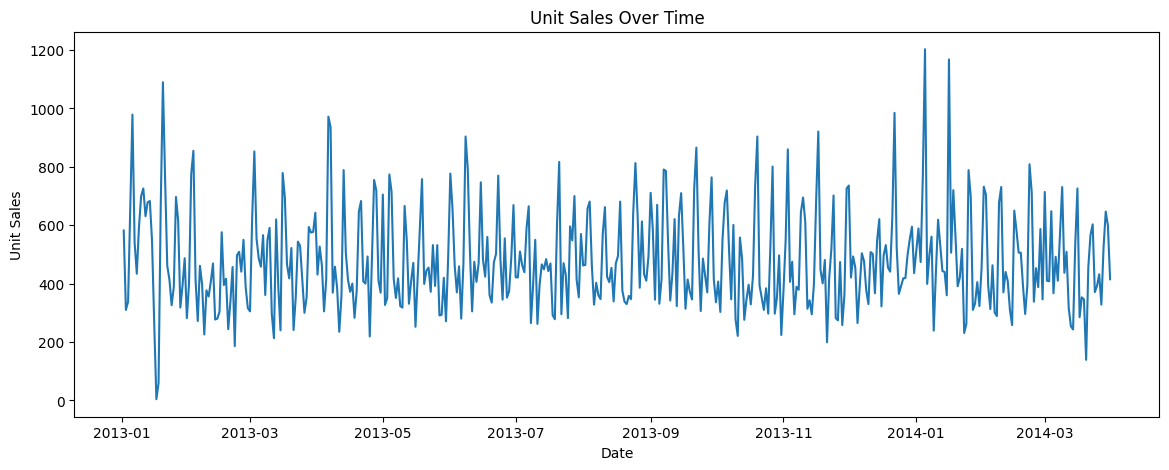

In [13]:
# Plot unit sales over time
plt.figure(figsize=(14, 5))
plt.plot(timeseries["date"], timeseries["unit_sales"])
plt.title("Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

# 4. Feature Engineering

In [14]:
# Create a working copy of the main time series
df = timeseries.copy()

In [16]:
# Display the first rows of the working dataframe
df.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [17]:
# Check the shape and columns of the working dataframe
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (454, 2)
Columns: ['date', 'unit_sales']


## Calendar Features

These features are created directly from the date column. They help capture recurring calendar patterns such as weekdays, weekends, month boundaries, and seasonal position within the year.

In [18]:
# Create basic calendar features from the date column
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

df.head()

,date,unit_sales,year,month,day,day_of_week
0,2013-01-02,582.0,2013,1,2,2
1,2013-01-03,310.0,2013,1,3,3
2,2013-01-04,338.0,2013,1,4,4
3,2013-01-05,654.0,2013,1,5,5
4,2013-01-06,979.0,2013,1,6,6


In [19]:
# Create additional calendar features
df["quarter"] = df["date"].dt.quarter
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df.head()

,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend
0,2013-01-02,582.0,2013,1,2,2,1,1,0
1,2013-01-03,310.0,2013,1,3,3,1,1,0
2,2013-01-04,338.0,2013,1,4,4,1,1,0
3,2013-01-05,654.0,2013,1,5,5,1,1,1
4,2013-01-06,979.0,2013,1,6,6,1,1,1


In [20]:
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

df.head()

,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,is_month_end
0,2013-01-02,582.0,2013,1,2,2,1,1,0,0,0
1,2013-01-03,310.0,2013,1,3,3,1,1,0,0,0
2,2013-01-04,338.0,2013,1,4,4,1,1,0,0,0
3,2013-01-05,654.0,2013,1,5,5,1,1,1,0,0
4,2013-01-06,979.0,2013,1,6,6,1,1,1,0,0


## Lag Features

Lag features use past sales values as predictors for the current day. They help the model capture short-term memory and repeating temporal patterns in the time series.

In [21]:
# Create lag features based on past sales values
df["lag_1"] = df["unit_sales"].shift(1)
df["lag_7"] = df["unit_sales"].shift(7)
df["lag_14"] = df["unit_sales"].shift(14)
df["lag_30"] = df["unit_sales"].shift(30)

In [22]:
# Display the new lag features
df[["date", "unit_sales", "lag_1", "lag_7", "lag_14", "lag_30"]].head(35)

,date,unit_sales,lag_1,lag_7,lag_14,lag_30
0,2013-01-02,582.0,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,582.0,NaN,NaN,NaN
2,2013-01-04,338.0,310.0,NaN,NaN,NaN
3,2013-01-05,654.0,338.0,NaN,NaN,NaN
4,2013-01-06,979.0,654.0,NaN,NaN,NaN
5,2013-01-07,541.0,979.0,NaN,NaN,NaN
6,2013-01-08,434.0,541.0,NaN,NaN,NaN
7,2013-01-09,593.0,434.0,582.0,NaN,NaN
8,2013-01-10,700.0,593.0,310.0,NaN,NaN
9,2013-01-11,726.0,700.0,338.0,NaN,NaN


## Rolling Features

Rolling features summarize recent sales behavior over fixed windows. They help the model capture short-term trends and local variability in the time series.

In [23]:
# Create rolling statistics based on past sales values
df["rolling_7d_mean"] = df["unit_sales"].shift(1).rolling(window=7).mean()
df["rolling_14d_mean"] = df["unit_sales"].shift(1).rolling(window=14).mean()
df["rolling_30d_mean"] = df["unit_sales"].shift(1).rolling(window=30).mean()
df["rolling_7d_std"] = df["unit_sales"].shift(1).rolling(window=7).std()

In [24]:
# Display the new rolling features
df[[
    "date",
    "unit_sales",
    "rolling_7d_mean",
    "rolling_14d_mean",
    "rolling_30d_mean",
    "rolling_7d_std"
]].head(35)

,date,unit_sales,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std
0,2013-01-02,582.0,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,NaN,NaN,NaN,NaN
2,2013-01-04,338.0,NaN,NaN,NaN,NaN
3,2013-01-05,654.0,NaN,NaN,NaN,NaN
4,2013-01-06,979.0,NaN,NaN,NaN,NaN
5,2013-01-07,541.0,NaN,NaN,NaN,NaN
6,2013-01-08,434.0,NaN,NaN,NaN,NaN
7,2013-01-09,593.0,548.285714,NaN,NaN,228.013680
8,2013-01-10,700.0,549.857143,NaN,NaN,228.322454
9,2013-01-11,726.0,605.571429,NaN,NaN,206.587235


## Oil Features

Oil-related features are added as external signals. They may help capture broader economic conditions that influence sales behavior over time.

In [25]:
# Merge the working dataframe with the processed oil dataset
df = df.merge(
    oil[["date", "oil_price_interpolated"]],
    on="date",
    how="left"
)

In [26]:
df[["date", "unit_sales", "oil_price_interpolated"]].head()

,date,unit_sales,oil_price_interpolated
0,2013-01-02,582.0,93.14
1,2013-01-03,310.0,92.97
2,2013-01-04,338.0,93.12
3,2013-01-05,654.0,NaN
4,2013-01-06,979.0,NaN


In [27]:
# Fill missing oil values after the merge
df["oil_price_interpolated"] = df["oil_price_interpolated"].ffill().bfill()

In [28]:
# Check missing values in the merged oil feature
df["oil_price_interpolated"].isna().sum()

np.int64(0)

In [29]:
# Create oil-based features
df["oil_lag_1"] = df["oil_price_interpolated"].shift(1)
df["oil_rolling_7d_mean"] = df["oil_price_interpolated"].shift(1).rolling(window=7).mean()

In [30]:
# Display the oil-based features
df[["date", "oil_price_interpolated", "oil_lag_1", "oil_rolling_7d_mean"]].head(10)

,date,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean
0,2013-01-02,93.14,NaN,NaN
1,2013-01-03,92.97,93.14,NaN
2,2013-01-04,93.12,92.97,NaN
3,2013-01-05,93.12,93.12,NaN
4,2013-01-06,93.12,93.12,NaN
5,2013-01-07,93.20,93.12,NaN
6,2013-01-08,93.21,93.20,NaN
7,2013-01-09,93.08,93.21,93.125714
8,2013-01-10,93.81,93.08,93.117143
9,2013-01-11,93.60,93.81,93.237143


## Holiday Features

Holiday features are added as binary indicators. They help the model detect whether special dates such as national, regional, or local holidays may influence sales.

In [31]:
# Create separate holiday flags by locale type
national_holidays = (
    holidays[holidays["locale"] == "National"][["date"]]
    .drop_duplicates()
    .copy()
)

regional_holidays = (
    holidays[holidays["locale"] == "Regional"][["date"]]
    .drop_duplicates()
    .copy()
)

local_holidays = (
    holidays[holidays["locale"] == "Local"][["date"]]
    .drop_duplicates()
    .copy()
)

In [32]:
national_holidays["is_national_holiday"] = 1
regional_holidays["is_regional_holiday"] = 1
local_holidays["is_local_holiday"] = 1

In [33]:
# Merge the national holiday flag into the working dataframe
df = df.merge(
    national_holidays,
    on="date",
    how="left"
)

In [34]:
# Merge the regional holiday flag into the working dataframe
df = df.merge(
    regional_holidays,
    on="date",
    how="left"
)

In [35]:
# Merge the local holiday flag into the working dataframe
df = df.merge(
    local_holidays,
    on="date",
    how="left"
)

In [36]:
# Fill missing holiday flags with 0
df["is_national_holiday"] = df["is_national_holiday"].fillna(0)
df["is_regional_holiday"] = df["is_regional_holiday"].fillna(0)
df["is_local_holiday"] = df["is_local_holiday"].fillna(0)

In [37]:
# Convert holiday flags to integer type
df["is_national_holiday"] = df["is_national_holiday"].astype(int)
df["is_regional_holiday"] = df["is_regional_holiday"].astype(int)
df["is_local_holiday"] = df["is_local_holiday"].astype(int)

In [38]:
# Check that holiday merges did not create duplicate dates

duplicate_dates_after_holidays = df["date"].duplicated().sum()

print("Duplicate dates after holiday merges:", duplicate_dates_after_holidays)

if duplicate_dates_after_holidays == 0:
    print("Check passed: each date appears only once.")
else:
    print("Warning: duplicate dates were created during holiday merging.")

Duplicate dates after holiday merges: 0
Check passed: each date appears only once.


In [39]:
# Display the holiday flags in the working dataframe
df[["date", "is_national_holiday", "is_regional_holiday", "is_local_holiday"]].head(10)

,date,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-01-02,0,0,0
1,2013-01-03,0,0,0
2,2013-01-04,0,0,0
3,2013-01-05,1,0,0
4,2013-01-06,0,0,0
5,2013-01-07,0,0,0
6,2013-01-08,0,0,0
7,2013-01-09,0,0,0
8,2013-01-10,0,0,0
9,2013-01-11,0,0,0


In [40]:
# Check the final list of columns after feature engineering
print(df.columns.tolist())

['date', 'unit_sales', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'oil_price_interpolated', 'oil_lag_1', 'oil_rolling_7d_mean', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']


In [41]:
# Check missing values after creating all features
df.isna().sum()

date                       0
unit_sales                 0
year                       0
month                      0
day                        0
day_of_week                0
quarter                    0
week_of_year               0
is_weekend                 0
is_month_start             0
is_month_end               0
lag_1                      1
lag_7                      7
lag_14                    14
lag_30                    30
rolling_7d_mean            7
rolling_14d_mean          14
rolling_30d_mean          30
rolling_7d_std             7
oil_price_interpolated     0
oil_lag_1                  1
oil_rolling_7d_mean        7
is_national_holiday        0
is_regional_holiday        0
is_local_holiday           0
dtype: int64

Rows with missing values were removed after feature creation. These missing values are expected because lag and rolling features require previous observations. Removing the first incomplete rows ensures that the final feature-based dataset can be used directly by regression models.

In [42]:
# Remove rows with missing values created by feature engineering
df = df.dropna().copy()

In [43]:
# Check the final shape of the feature-engineered dataframe
print("Final dataframe shape:", df.shape)

Final dataframe shape: (424, 25)


In [44]:
# Check that no missing values remain after dropping incomplete rows
print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [45]:
# Display the final feature-engineered dataframe
df.head()

,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,...,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
30,2013-02-01,401.0,2013,2,1,4,1,5,0,1,...,454.571429,497.071429,520.833333,154.059358,97.46,97.65,96.378571,0,0,0
31,2013-02-02,775.0,2013,2,2,5,1,5,1,0,...,456.285714,521.428571,514.800000,153.272866,97.46,97.46,96.708571,0,0,0
32,2013-02-03,855.0,2013,2,3,6,1,5,1,0,...,467.428571,529.142857,530.300000,174.986530,97.46,97.46,97.038571,0,0,0
33,2013-02-04,411.0,2013,2,4,0,1,6,0,0,...,501.571429,512.357143,547.533333,224.981375,96.21,97.46,97.368571,0,0,0
34,2013-02-05,272.0,2013,2,5,1,1,6,0,0,...,514.857143,487.428571,539.433333,214.852219,96.68,96.21,97.405714,0,0,0


In [46]:
# Final validation of the feature-engineered dataset before saving

print("Final feature-engineered dataset validation")
print("-" * 50)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Final feature-engineered dataset validation
--------------------------------------------------
Shape: (424, 25)
Date range: 2013-02-01 00:00:00 to 2014-03-31 00:00:00

Missing values:
Series([], dtype: int64)

Duplicate dates:
0

Columns:
['date', 'unit_sales', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'oil_price_interpolated', 'oil_lag_1', 'oil_rolling_7d_mean', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,...,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
30,2013-02-01,401.0,2013,2,1,4,1,5,0,1,...,454.571429,497.071429,520.833333,154.059358,97.46,97.65,96.378571,0,0,0
31,2013-02-02,775.0,2013,2,2,5,1,5,1,0,...,456.285714,521.428571,514.800000,153.272866,97.46,97.46,96.708571,0,0,0
32,2013-02-03,855.0,2013,2,3,6,1,5,1,0,...,467.428571,529.142857,530.300000,174.986530,97.46,97.46,97.038571,0,0,0
33,2013-02-04,411.0,2013,2,4,0,1,6,0,0,...,501.571429,512.357143,547.533333,224.981375,96.21,97.46,97.368571,0,0,0
34,2013-02-05,272.0,2013,2,5,1,1,6,0,0,...,514.857143,487.428571,539.433333,214.852219,96.68,96.21,97.405714,0,0,0


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,...,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
449,2014-03-27,328.0,2014,3,27,3,1,13,0,0,...,422.857143,407.285714,449.700000,152.001566,101.25,100.61,99.987143,0,0,0
450,2014-03-28,523.0,2014,3,28,4,1,13,0,0,...,449.857143,412.571429,445.533333,101.609430,101.73,101.25,100.211429,0,0,0
451,2014-03-29,647.0,2014,3,29,5,1,13,1,0,...,459.428571,432.571429,450.033333,105.370548,101.73,101.73,100.462857,0,0,0
452,2014-03-30,599.0,2014,3,30,6,1,13,1,0,...,470.857143,440.571429,452.033333,122.007416,101.73,101.73,100.714286,0,0,0
453,2014-03-31,415.0,2014,3,31,0,1,14,0,0,...,470.285714,431.500000,460.466667,121.292641,101.57,101.73,100.965714,0,0,0


In [47]:
# Save the final feature-engineered dataframe
df.to_csv("../../data/processed/feature_engineered_timeseries.csv", index=False)

## Feature Engineering Summary

At this stage, the time series has been transformed into a structured feature-based dataset.
The final dataframe is clean, contains no missing values, and is ready for the next step: train-test split and model training.